# Regresión Lineal - Accidentes de tránsito en Bogotá

## Notebook 2: Agregación diaria y construcción de features

Continúa desde `01_exploracion_y_limpieza.ipynb`. Parte del dataset ya limpio (`data/processed/accidentes_limpios.csv`) y construye la serie diaria de accidentes por localidad.

In [17]:
import pandas as pd
from pathlib import Path

ruta_datos_limpios = Path.cwd().parent / "data" / "processed" / "accidentes_limpios.csv"

df_clean = pd.read_csv(ruta_datos_limpios, parse_dates=["FECHA_HORA_ACC"])
df_clean.shape

(199093, 16)

## 1. Agregación diaria por localidad

Agrupamos por fecha (sin hora) y localidad, contando cuántos accidentes hubo en cada combinación.

In [18]:
group_accidents_by_date_and_location = (
    df_clean.groupby([df_clean['FECHA_HORA_ACC'].dt.date, 'LOCALIDAD'])
            .size()
            .reset_index(name='num_accidentes')
            .rename(columns={'FECHA_HORA_ACC': 'fecha'})
)

group_accidents_by_date_and_location.shape

(41229, 3)

In [19]:
group_accidents_by_date_and_location.head(10)

,fecha,LOCALIDAD,num_accidentes
0,2015-01-01,BOSA,1
1,2015-01-01,CHAPINERO,1
2,2015-01-01,CIUDAD BOLIVAR,3
3,2015-01-01,ENGATIVA,2
4,2015-01-01,FONTIBON,1
5,2015-01-01,KENNEDY,1
6,2015-01-01,PUENTE ARANDA,1
7,2015-01-01,SUBA,2
8,2015-01-02,BARRIOS UNIDOS,1
9,2015-01-02,BOSA,2


## 2. Completar combinaciones fecha-localidad

La agregación anterior solo tiene filas para combinaciones donde ocurrió al menos un accidente. Para una serie temporal completa, generamos todas las combinaciones posibles de fecha x localidad y rellenamos con 0 los días sin accidentes.

In [20]:
all_dates = pd.date_range(
    start=group_accidents_by_date_and_location['fecha'].min(),
    end=group_accidents_by_date_and_location['fecha'].max(),
    freq='D'
)

unique_locations = df_clean['LOCALIDAD'].unique()

all_combinations = pd.MultiIndex.from_product(
    [all_dates, unique_locations],
    names=['fecha', 'LOCALIDAD']
)

group_accidents_by_date_and_location['fecha'] = pd.to_datetime(group_accidents_by_date_and_location['fecha'])

all_registers = (
    group_accidents_by_date_and_location.set_index(['fecha', 'LOCALIDAD'])
                     .reindex(all_combinations, fill_value=0)
                     .reset_index()
)

all_registers.shape

(46455, 3)

In [21]:
all_registers.head(10)

,fecha,LOCALIDAD,num_accidentes
0,2015-01-01,ENGATIVA,2
1,2015-01-01,PUENTE ARANDA,1
2,2015-01-01,USAQUEN,0
3,2015-01-01,CIUDAD BOLIVAR,3
4,2015-01-01,LOS MARTIRES,0
5,2015-01-01,SUBA,2
6,2015-01-01,FONTIBON,1
7,2015-01-01,USME,0
8,2015-01-01,TEUSAQUILLO,0
9,2015-01-01,BARRIOS UNIDOS,0


## 3. Ingeniería de features de fecha

A partir de `fecha` derivamos columnas que probablemente influyen en la cantidad de accidentes: día de la semana, mes y año.

In [22]:
all_registers['dia_semana'] = all_registers['fecha'].dt.day_name()
all_registers['mes'] = all_registers['fecha'].dt.month
all_registers['anio'] = all_registers['fecha'].dt.year

all_registers.head()

,fecha,LOCALIDAD,num_accidentes,dia_semana,mes,anio
0,2015-01-01,ENGATIVA,2,Thursday,1,2015
1,2015-01-01,PUENTE ARANDA,1,Thursday,1,2015
2,2015-01-01,USAQUEN,0,Thursday,1,2015
3,2015-01-01,CIUDAD BOLIVAR,3,Thursday,1,2015
4,2015-01-01,LOS MARTIRES,0,Thursday,1,2015


## 4. Visualizaciones exploratorias

### Distribución de accidentes diarios

Histograma de `num_accidentes` para ver cómo se distribuyen los valores por combinación día-localidad (muchos días con pocos o cero accidentes, algunos con picos altos).

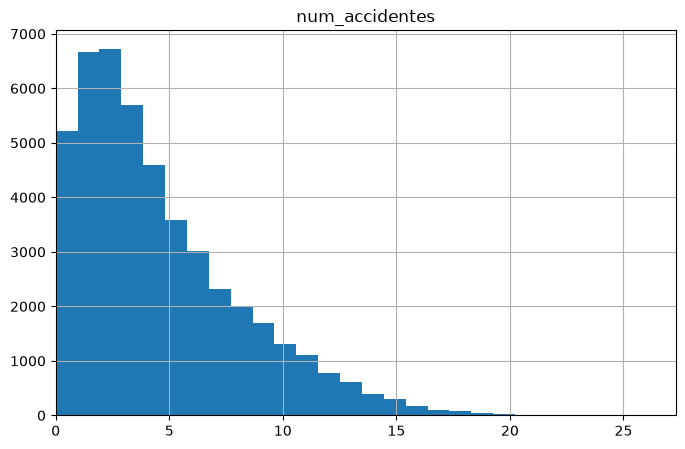

In [23]:
%matplotlib inline
import matplotlib.pyplot as plt

ax = all_registers[['num_accidentes']].hist(bins=27, figsize=(8,5))
ax[0][0].set_xlim(left=0)
plt.show()

**Qué representa:** busca mostrar cómo se distribuye `num_accidentes` entre todas las combinaciones día-localidad, para ver si la variable objetivo está sesgada (muchos días con pocos o cero accidentes y pocos días con picos altos) o si se acerca a una distribución normal. Esto ayuda a decidir si conviene transformar la variable antes de entrenar el modelo de regresión.

### Promedio de accidentes por día de la semana

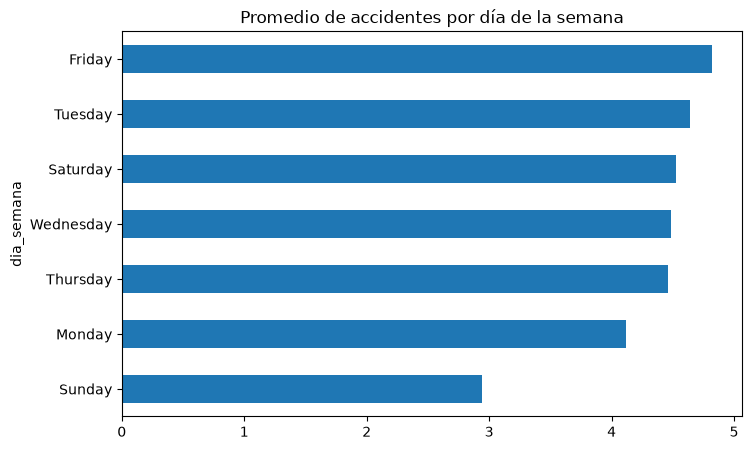

In [24]:
plt.figure(figsize=(8,5))
all_registers.groupby('dia_semana')['num_accidentes'].mean().sort_values().plot(kind='barh')
plt.title('Promedio de accidentes por día de la semana')
plt.show()

**Qué representa:** busca identificar si el día de la semana influye en la cantidad de accidentes (por ejemplo, más accidentes entre semana por mayor flujo vehicular, o menos los fines de semana). Si se ve una diferencia clara entre días, `dia_semana` sería una variable útil para el modelo.

### Promedio de accidentes por mes

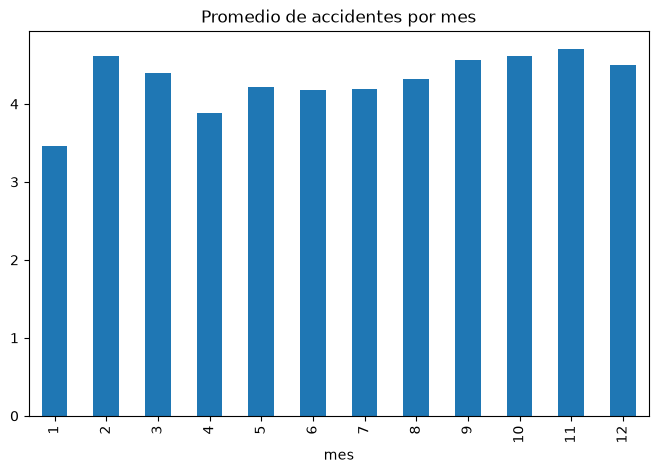

In [25]:
all_registers.groupby('mes')['num_accidentes'].mean().plot(kind='bar', figsize=(8,5))
plt.title('Promedio de accidentes por mes')
plt.show()

**Qué representa:** busca identificar estacionalidad mensual en los accidentes (por ejemplo, meses de vacaciones, temporada de lluvias o fin de año con más tráfico). Si hay variación notable entre meses, `mes` aportaría valor predictivo al modelo.

### Promedio de accidentes por localidad

Se espera bastante variación entre localidades, consistente con lo que ya vimos en los conteos del notebook 1.

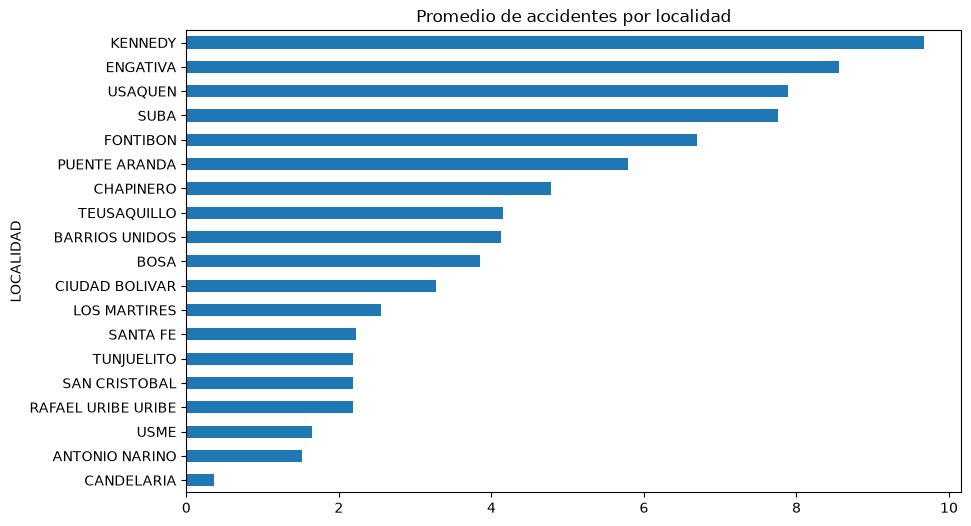

In [26]:
all_registers.groupby('LOCALIDAD')['num_accidentes'].mean().sort_values().plot(kind='barh', figsize=(10,6))
plt.title('Promedio de accidentes por localidad')
plt.show()

**Qué representa:** busca confirmar qué tan determinante es la localidad en el número de accidentes diarios. La gran variación esperada entre localidades (ya vista en los conteos del notebook 1) sugiere que `LOCALIDAD` debe incluirse como variable categórica en el modelo, probablemente codificada con one-hot encoding.

### Serie completa de accidentes diarios (2015-2021)

Sumamos `num_accidentes` por fecha (todas las localidades juntas) para ver la tendencia general en el tiempo, y marcamos el inicio de la cuarentena estricta por COVID-19.

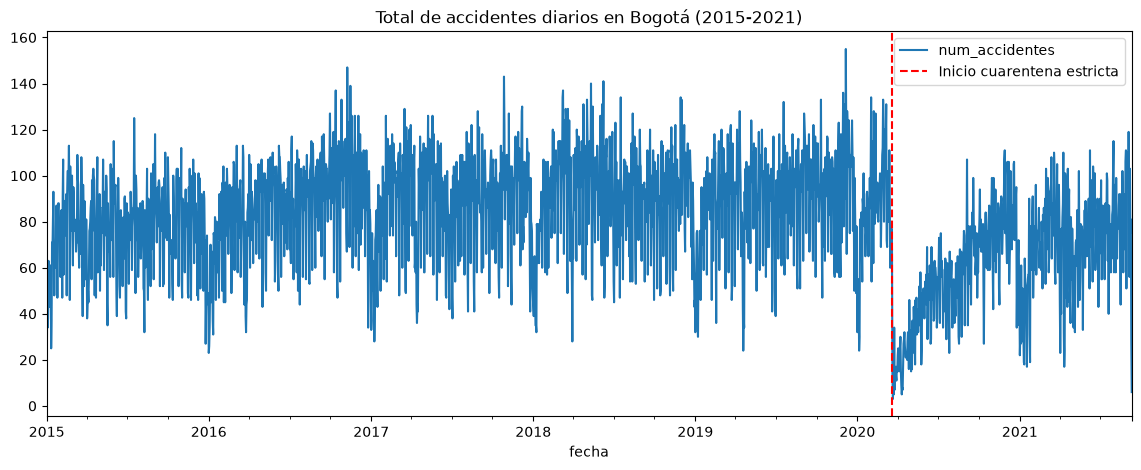

In [27]:
serie_diaria = all_registers.groupby('fecha')['num_accidentes'].sum()

plt.figure(figsize=(14,5))
serie_diaria.plot()
plt.axvline(pd.Timestamp('2020-03-20'), color='red', linestyle='--', label='Inicio cuarentena estricta')
plt.title('Total de accidentes diarios en Bogotá (2015-2021)')
plt.legend()
plt.show()

**Qué representa:** busca detectar quiebres estructurales en la serie de tiempo. La cuarentena estricta de 2020 fue un evento anómalo que redujo drásticamente el tráfico (y por lo tanto los accidentes) de forma artificial. Como no queremos que el modelo aprenda ese patrón atípico como si fuera parte del comportamiento normal, en el notebook de modelado vamos a filtrar los datos para trabajar solo con el periodo anterior a la pandemia.

## 5. Guardar dataset agregado

Persistimos `all_registers` (serie diaria por localidad, ya con las features de fecha) en `data/processed/` para que el notebook de modelado parta de aquí.

In [28]:
ruta_salida = Path.cwd().parent / "data" / "processed" / "accidentes_diarios_localidad.csv"
ruta_salida.parent.mkdir(parents=True, exist_ok=True)

all_registers.to_csv(ruta_salida, index=False)
ruta_salida

PosixPath('/Users/jampier/Desktop/ESP. CIENCIA_DE_DATOS/Machine learning/Regresion_lineal/data/processed/accidentes_diarios_localidad.csv')

## Próximos pasos

Continúa en `03_modelo_regresion.ipynb`: filtro de datos pre-pandemia, split cronológico, entrenamiento y evaluación del modelo de regresión lineal.